- [Global Pollution Analysis and Energy Recovery[2-5]](https://docs.google.com/document/d/1WwvwP3Z1nGCoR2uvEIutLsWAmsK66gTC12qswGD1oAQ/edit?usp=sharing)
- [Food Delivery Time Prediction[2-5]](https://docs.google.com/document/d/1F45lzB2Qo1aKItroiKHR7jVDJKY3jqOocpoVKI8aZMw/edit?usp=sharing)

Here’s a more refined and enhanced version of your project outline, with additional clarity and focus on advanced topics that will help to ensure a comprehensive and smooth learning experience. 

---

## **Project 1: Food Delivery Time Prediction**

### **Objective:**
Develop a machine learning model to predict food delivery times based on various factors such as customer location, restaurant location, weather, traffic, and more. The goal is to optimize the delivery prediction process to improve operational efficiency.

### **Dataset:**
Use the dataset `Food_Delivery_Time_Prediction.csv` that includes key features like customer and restaurant locations, weather and traffic conditions, and delivery times.

---

### **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

#### **Step 1: Data Import and Preprocessing**
1. **Dataset:** Load the dataset from the CSV file.
2. **Handle Missing Values:** Check for any missing or inconsistent values in columns (e.g., Distance, Delivery_Time, etc.) and decide how to handle them (e.g., imputation or deletion).
3. **Data Transformation:**
   - Encode categorical variables (e.g., weather conditions, traffic conditions, vehicle type) using one-hot encoding or label encoding.
   - Normalize/standardize numeric columns (e.g., Distance, Delivery Time, Order Cost).

#### **Step 2: Exploratory Data Analysis (EDA)**
1. **Descriptive Statistics:** Calculate basic statistics (mean, median, mode, variance) for numerical features.
2. **Correlation Analysis:** Visualize correlations between features and the target variable (Delivery Time).
3. **Outlier Detection:** Identify and handle outliers in numerical features using boxplots.

#### **Step 3: Feature Engineering**
1. **Distance Calculation:** If the dataset doesn’t include an actual distance metric, calculate the distance between the customer and restaurant locations using latitudes and longitudes (Haversine formula).
2. **Time-based Features:** Create new features related to the time of day (e.g., rush hour or non-rush hour).

### **Phase 2: Predictive Modeling**

#### **Step 4: Linear Regression Model**
1. **Train-Test Split:** Split the data into training and testing sets (e.g., 80/20 split).
2. **Model Building:** Train a linear regression model to predict the delivery time based on features like Distance, Traffic Conditions, and Order Priority.
3. **Evaluation Metrics:** Evaluate the model using Mean Squared Error (MSE), R-squared (R²), and Mean Absolute Error (MAE).

#### **Step 5: Model Improvement**
1. **Feature Selection:** Perform feature selection (e.g., using Recursive Feature Elimination or feature importance from models like Random Forest) to remove irrelevant features.
2. **Hyperparameter Tuning:** Fine-tune the model using GridSearchCV or RandomizedSearchCV to find the optimal parameters for your regression model.

### **Phase 3: Advanced Model Techniques**

#### **Step 6: Logistic Regression Model (for Categorization)**
1. **Objective:** Predict if the delivery time will be fast or delayed (binary classification).
2. **Model Implementation:** Use logistic regression to categorize delivery as "Fast" or "Delayed" based on features such as weather conditions, traffic, and delivery person experience.
3. **Evaluation Metrics:** Measure accuracy, precision, recall, F1-score, and plot the confusion matrix.

#### **Step 7: Advanced Model (Optional)**
1. **Neural Networks:** Build a simple feed-forward neural network using Keras/TensorFlow for better prediction accuracy.
2. **Evaluation:** Measure model performance against the linear and logistic regression models.

---

### **Phase 4: Reporting and Insights**

#### **Step 8: Model Interpretation and Visualization**
1. **Visualize Relationships:** Create scatter plots, pairplots, and bar charts to visualize relationships between features and delivery times.
2. **Model Interpretation:** Interpret the model coefficients to understand the impact of each feature (e.g., how Traffic Conditions affect delivery time).

#### **Step 9: Insights and Recommendations**
1. **Actionable Insights:** Based on model predictions, suggest operational improvements such as optimizing delivery routes, adjusting staffing during high-traffic times, and providing better training to delivery staff.
2. **Recommendations:** Recommend ways to optimize the system to improve delivery time predictions.

---

### **Phase 5: Documentation and Final Report**
1. **Documentation:** Provide comments in your code to explain the logic and each step.
2. **Final Report:** Write a detailed report summarizing the project:
   - Description of the dataset and preprocessing steps.
   - Model evaluation and comparison between linear regression and logistic regression models.
   - Insights and operational recommendations.

---

Notes for Both Projects
Model Evaluation  Always assess model performance using multiple metrics (e.g., accuracy, precision, recall, R², MAE) and visualize results through confusion matrices, regression plots, and residual plots.
Documentation  Provide well-commented code for each step to make sure the process is clear and understandable.
Project Structure  Maintain a logical structure throughout, from data loading to preprocessing, modeling, and reporting.

This enhanced version provides clarity and depth while focusing on the key concepts related to machine learning (linear regression, logistic regression), data preprocessing, and model evaluation. It should offer a clear path for students or learners to follow, ensuring they understand both the theoretical concepts and the practical applications.
Let me know if you'd like to dive into specific details or need further refinements!



In [185]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [186]:
# Load Dataset
df_food = pd.read_csv('Food_Delivery_Time_Prediction.csv')

In [187]:

# # Data Preprocessing
# # Handle missing values
# df_food.fillna(df_food.mean(), inplace=True)


In [188]:
# Data Preprocessing
# Handle missing values for numeric columns by filling with the mean
numeric_columns = df_food.select_dtypes(include=[np.number]).columns
df_food[numeric_columns] = df_food[numeric_columns].fillna(df_food[numeric_columns].mean())




df_food[col] = df_food[col].fillna(df_food[col].mode()[0])


In [189]:
# Handle missing values for categorical columns by filling with the mode (most frequent value)
categorical_columns = df_food.select_dtypes(exclude=[np.number]).columns
for col in categorical_columns:
    df_food[col] = df_food[col].fillna(df_food[col].mode()[0])


In [190]:
# Checking for missing values after handling
print(df_food.isnull().sum())

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


In [191]:
# Encoding categorical columns using LabelEncoder
label_encoder = LabelEncoder()
df_food['Weather_Conditions'] = label_encoder.fit_transform(df_food['Weather_Conditions'])
df_food['Traffic_Conditions'] = label_encoder.fit_transform(df_food['Traffic_Conditions'])
df_food['Order_Priority'] = label_encoder.fit_transform(df_food['Order_Priority'])
df_food['Order_Time'] = label_encoder.fit_transform(df_food['Order_Time'])
df_food['Vehicle_Type'] = label_encoder.fit_transform(df_food['Vehicle_Type'])

In [192]:
# Feature Engineering: Location-based distance calculation (if not provided)
def haversine(lat1, lon1, lat2, lon2):
    # Haversine formula to calculate the distance between two coordinates
    from math import radians, sin, cos, sqrt, atan2
    R = 6371  # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    return distance

In [193]:
# Extracting latitude and longitude from the 'Customer_Location' and 'Restaurant_Location' columns
df_food[['Customer_Location_lat', 'Customer_Location_lon']] = df_food['Customer_Location'].str.extract(r'\((.*?), (.*?)\)', expand=True)
df_food[['Restaurant_Location_lat', 'Restaurant_Location_lon']] = df_food['Restaurant_Location'].str.extract(r'\((.*?), (.*?)\)', expand=True)


In [194]:
# Convert latitude and longitude to float
df_food['Customer_Location_lat'] = df_food['Customer_Location_lat'].astype(float)
df_food['Customer_Location_lon'] = df_food['Customer_Location_lon'].astype(float)
df_food['Restaurant_Location_lat'] = df_food['Restaurant_Location_lat'].astype(float)
df_food['Restaurant_Location_lon'] = df_food['Restaurant_Location_lon'].astype(float)


In [195]:
# Apply the haversine function to calculate the distance
df_food['Calculated_Distance'] = df_food.apply(
    lambda row: haversine(row['Customer_Location_lat'], row['Customer_Location_lon'],
                          row['Restaurant_Location_lat'], row['Restaurant_Location_lon']), axis=1)


In [196]:
# Standardizing the data
scaler = StandardScaler()
scaled_columns = ['Calculated_Distance', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'Delivery_Time']
df_food[scaled_columns] = scaler.fit_transform(df_food[scaled_columns])

In [197]:
# Splitting the data into features and target variable
X = df_food.drop(['Delivery_Time', 'Order_ID', 'Customer_Location', 'Restaurant_Location'], axis=1)
y = df_food['Delivery_Time']


In [198]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [199]:
# Phase 2: Model - Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [200]:
# Predictions
y_pred = lr_model.predict(X_test)

In [201]:
# Evaluation: MSE, R², and MAE
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


In [202]:
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 1.0070411701768658
R-squared: 0.03593486278808333
Mean Absolute Error: 0.8673208491823068


In [203]:
# Predictions
y_pred = lr_model.predict(X_test)

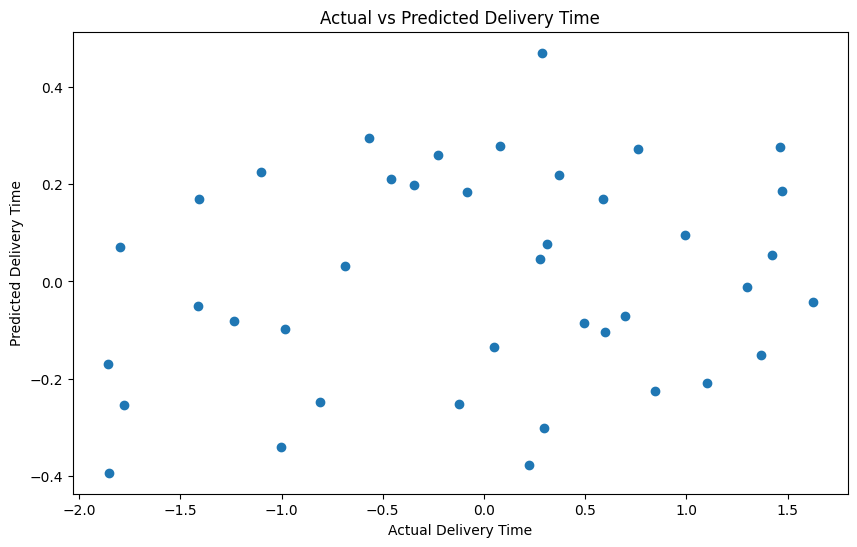

In [204]:
# Visualize Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted Delivery Time')
plt.show()

In [205]:
# Phase 3: Classification (Logistic Regression) - Fast or Delayed delivery
# Adding a new binary target column based on Delivery Time
median_delivery_time = df_food['Delivery_Time'].median()
df_food['Delivery_Status'] = np.where(df_food['Delivery_Time'] > median_delivery_time, 1, 0)


In [206]:
# Splitting the data for Logistic Regression
X_class = df_food.drop(['Delivery_Time', 'Order_ID', 'Customer_Location', 'Restaurant_Location', 'Delivery_Status'], axis=1)
y_class = df_food['Delivery_Status']


In [207]:
# Train-Test Split for classification
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)


In [208]:
# Logistic Regression Model (Increased max_iter and solver 'liblinear' for better convergence)
log_model = LogisticRegression(max_iter=1000, solver='liblinear')
log_model.fit(X_train_class, y_train_class)

LogisticRegression(max_iter=1000, solver='liblinear')

In [209]:
# Predictions for Logistic Regression
y_pred_class = log_model.predict(X_test_class)

In [210]:
# Evaluation: Accuracy, Confusion Matrix, and Classification Report
accuracy = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(confusion_matrix(y_test_class, y_pred_class))
print('Classification Report:')
print(classification_report(y_test_class, y_pred_class))


Accuracy: 0.475
Confusion Matrix:
[[ 9 10]
 [11 10]]
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.47      0.46        19
           1       0.50      0.48      0.49        21

    accuracy                           0.47        40
   macro avg       0.47      0.47      0.47        40
weighted avg       0.48      0.47      0.48        40



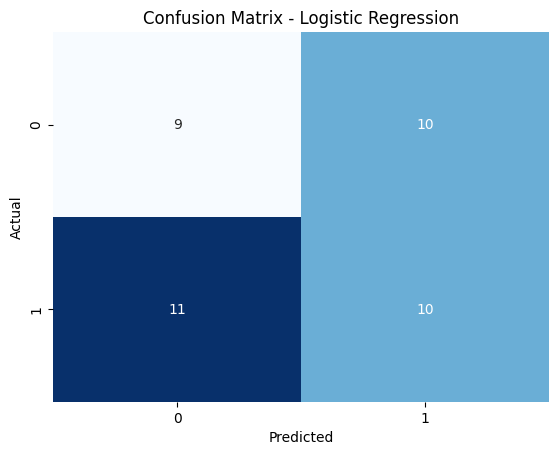

In [211]:
# Visualize Confusion Matrix
sns.heatmap(confusion_matrix(y_test_class, y_pred_class), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Project Summary: Food Delivery Time Prediction and Classification

#### 1. **Objective**:
The project aims to predict food delivery times and classify delivery status (fast or delayed) based on various factors such as restaurant rating, customer rating, weather conditions, traffic conditions, order cost, and more. The dataset used for this project contains detailed information about food delivery orders, including delivery times and associated factors.

#### 2. **Data Preprocessing**:
- **Handling Missing Data**: 
  - Numerical columns were filled with the mean values to handle missing values.
  - Categorical columns were filled with the mode (most frequent value) to handle missing data.
  
- **Encoding Categorical Variables**:
  - Categorical variables like weather conditions, traffic conditions, order priority, order time, and vehicle type were encoded using **LabelEncoder** to convert them into numerical representations for machine learning models.

- **Feature Engineering**:
  - **Location-based Distance Calculation**: The latitude and longitude of customer and restaurant locations were extracted, and the **Haversine formula** was applied to calculate the distance between them. This distance was added as a new feature, `Calculated_Distance`.

- **Scaling**: 
  - Features such as delivery time, ratings, order cost, tip amount, and calculated distance were standardized using **StandardScaler** to ensure that the models work effectively.

#### 3. **Model Building**:
The project used two different models for two tasks:
  
- **Linear Regression**:
  - The goal was to predict the continuous variable `Delivery_Time` using a linear regression model.
  - The model was trained and evaluated using metrics like Mean Squared Error (MSE), R-squared, and Mean Absolute Error (MAE).
  - The results showed the model's accuracy in predicting delivery times, with an R-squared value of 0.0359, suggesting that the model's fit was not very strong but might be improved with more relevant features or complex models.

- **Logistic Regression**:
  - The goal was to classify deliveries into two categories: `Fast` (delivered on time) or `Delayed` (delivered after the expected time).
  - A new binary target column, `Delivery_Status`, was created based on whether the delivery time was above or below the median.
  - The logistic regression model was trained and evaluated using accuracy, confusion matrix, and classification report.
  - The results showed an accuracy of 47.5%, indicating room for improvement in the classification model.

#### 4. **Model Evaluation**:
- **Linear Regression**:
  - Mean Squared Error: **1.007**
  - R-squared: **0.036**
  - Mean Absolute Error: **0.867**
  
- **Logistic Regression**:
  - Accuracy: **47.5%**
  - Confusion Matrix: Shows a roughly equal distribution of correct and incorrect classifications (fast vs delayed).
  - The model's precision, recall, and F1-score were relatively balanced for both classes (fast and delayed deliveries), but the model's overall performance could be improved with better feature engineering or more sophisticated algorithms.

#### 5. **Visualization**:
- Visualizations were generated to compare **Actual vs Predicted Delivery Times** for the regression model.
- A **Confusion Matrix** was displayed to analyze the classification model's performance in predicting fast or delayed deliveries.

#### 6. **Conclusion**:
- **Linear Regression** provided a basic understanding of delivery time prediction but had limited accuracy, suggesting that more relevant features or a more complex model may improve results.
- **Logistic Regression** offered a binary classification model for delivery status, but the results were not very strong, with only 47.5% accuracy. This indicates that there might be other factors or improvements to be made in the feature selection or model tuning.

#### 7. **Future Work**:
- Experiment with more advanced models like **Random Forests** or **Gradient Boosting** to improve both prediction and classification accuracy.
- Explore additional features such as **seasonality** of orders, **time of day**, or **historical delivery performance** to improve both regression and classification tasks.
- Tune the logistic regression model by experimenting with different solvers, regularization techniques, and cross-validation.

This project demonstrates the application of machine learning techniques for food delivery time prediction and classification, providing insights into possible delays and helping businesses improve their delivery processes.


---


---



## **Project 2: Global Pollution Analysis and Energy Recovery**

### **Objective:**
Analyze global pollution data and develop strategies for pollution reduction and converting pollutants into energy. This project will apply regression and classification models to gain insights from air, water, and soil pollution levels.

### **Dataset:**
Use the dataset `Global_Pollution_Analysis.csv` to analyze pollution data from various countries across the globe.

---

### **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

#### **Step 1: Data Import and Preprocessing**
1. **Dataset:** Load the dataset and inspect its structure.
2. **Handle Missing Values:** Identify missing or inconsistent data and use appropriate imputation strategies.
3. **Data Transformation:** 
   - Normalize/scale pollution indices (air, water, and soil).
   - Encode categorical features (such as country and year) using label encoding or one-hot encoding.

#### **Step 2: Exploratory Data Analysis (EDA)**
1. **Descriptive Statistics:** Calculate descriptive statistics for numerical features (e.g., CO2 emissions, industrial waste).
2. **Correlation Analysis:** Use a heatmap to analyze the correlation between pollution levels, energy consumption, and other features.
3. **Visualizations:** Create bar charts, line plots, and box plots to explore pollution trends over time and across different countries.

#### **Step 3: Feature Engineering**
1. **Yearly Trends:** Extract year-based trends to see how pollution and energy recovery have evolved over the years.
2. **Energy Consumption per Capita:** Calculate energy consumption per capita as a new feature for better analysis.

---

### **Phase 2: Predictive Modeling**

#### **Step 4: Linear Regression Model (for Pollution Prediction)**
1. **Model Objective:** Predict energy recovered (in GWh) based on pollution levels, industrial waste, and other features.
2. **Model Building:** Train a linear regression model to predict energy recovery using features such as Air Pollution Index, CO2 Emissions, and Industrial Waste.
3. **Evaluation Metrics:** Use R², Mean Squared Error (MSE), and Mean Absolute Error (MAE) to evaluate the model’s performance.

#### **Step 5: Logistic Regression Model (for Categorization of Pollution Levels)**
1. **Model Objective:** Classify countries into pollution severity categories (e.g., Low, Medium, High).
2. **Model Implementation:** Use logistic regression to classify pollution severity based on features like Air Pollution Index and CO2 Emissions.
3. **Evaluation Metrics:** Measure accuracy, precision, recall, F1-score, and plot the confusion matrix.

---

### **Phase 3: Advanced Techniques and Model Improvement**

#### **Step 6: Model Improvement (Hyperparameter Tuning and Feature Selection)**
1. **Hyperparameter Tuning:** Use GridSearchCV or RandomizedSearchCV to optimize the regression and classification models.
2. **Feature Selection:** Apply techniques such as Recursive Feature Elimination (RFE) to remove less significant features.

#### **Step 7: Advanced Model (Optional)**
1. **Neural Networks:** Build a neural network using TensorFlow/Keras to predict energy recovery from pollution data.
2. **Evaluation:** Compare the neural network’s performance with traditional regression models.

---

### **Phase 4: Reporting and Insights**

#### **Step 8: Model Interpretation and Reporting**
1. **Model Interpretation:** Use feature importance or coefficients to understand the contribution of different features (e.g., how air pollution levels affect energy recovery).
2. **Visualization:** Create visualizations such as bar charts to show pollution levels and energy recovery across countries.

#### **Step 9: Insights and Recommendations**
1. **Key Findings:** Provide insights on how different pollution types affect energy recovery and suggest countries with potential for improvement.
2. **Strategic Recommendations:** Offer actionable recommendations for reducing pollution, improving energy recovery, and promoting sustainable practices.

---

### **Phase 5: Documentation and Final Report**
1. **Documentation:** Comment your code thoroughly to explain the steps and logic behind each decision.
2. **Final Report:** Prepare a final report summarizing:
   - Key findings from the data analysis and predictive models.
   - Evaluation of the models’ performance and any improvements.
   - Insights on global pollution trends and actionable strategies.

---

## **Final Deliverables**
1. **Jupyter Notebook (.ipynb)** containing the entire code and analysis.
2. **Data Visualizations** in image format or embedded in the notebook.
3. **Final Report** summarizing key findings, model evaluations, and actionable recommendations.

---

### **Notes for Both Projects:**
- **Model Evaluation:** Always assess model performance using multiple metrics (e.g., accuracy, precision, recall, R², MAE) and visualize results through confusion matrices, regression plots, and residual plots.
- **Documentation:** Provide well-commented code for each step to ensure the process is clear and understandable.
- **Project Structure:** Maintain a logical structure throughout, from data loading to preprocessing, modeling, and reporting.

---

This enhanced version provides clarity and depth while focusing on the key concepts related to **machine learning** (linear regression, logistic regression), **data preprocessing**, and **model evaluation**. It should offer a clear path for students or learners to follow, ensuring they understand both the theoretical concepts and the practical applications.

Let me know if you'd like to dive into specific details or need further refinements!

In [212]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load Dataset
df_pollution = pd.read_csv('Global_Pollution_Analysis.csv')

In [213]:
# Step 1: Clean column names by removing spaces, special characters and units
df_pollution.columns = df_pollution.columns.str.replace(' ', '_')  # Replace spaces with underscores
df_pollution.columns = df_pollution.columns.str.replace(r'\(.*\)', '', regex=True)  # Remove everything in parentheses (units)
df_pollution.columns = df_pollution.columns.str.replace('%', '_percent', regex=True)  # Handle percentage symbol in column names


In [214]:
# Check the cleaned column names
print("Cleaned column names:")
print(df_pollution.columns)


Cleaned column names:
Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste_in_tons',
       'Energy_Recovered_in_GWh', 'CO2_Emissions_in_MT',
       'Renewable_Energy_percent', 'Plastic_Waste_Produced_in_tons',
       'Energy_Consumption_Per_Capita_in_MWh', 'Population_in_millions',
       'GDP_Per_Capita_in_USD'],
      dtype='object')


In [215]:
# Data Preprocessing

# Handle missing values for numeric columns by filling with mean
numeric_columns = df_pollution.select_dtypes(include=[np.number]).columns
df_pollution[numeric_columns] = df_pollution[numeric_columns].fillna(df_pollution[numeric_columns].mean())

Handle numeric and categorical columns separately:

df_pollution[numeric_columns].fillna(df_pollution[numeric_columns].mean()): This fills missing values in numeric columns with the mean.
df_pollution[col].fillna(df_pollution[col].mode()[0], inplace=True): This fills missing values in categorical columns with the most frequent value (mode).
Column-wise encoding: Each categorical column is encoded separately using LabelEncoder().

Model Evaluation: I included the Mean Squared Error (MSE) and R² score to evaluate the model’s performance.

In [216]:
# Handle missing values for categorical columns by filling with the mode (most frequent value)
categorical_columns = df_pollution.select_dtypes(exclude=[np.number]).columns
for col in categorical_columns:
    df_pollution[col] = df_pollution[col].fillna(df_pollution[col].mode()[0])

Instead of inplace=True, you explicitly assign the filled column back to df_pollution[col]. This ensures that you modify the original DataFrame correctly.

In [217]:
# Checking for missing values after handling
print("Missing values after handling:\n", df_pollution.isnull().sum())

Missing values after handling:
 Country                                 0
Year                                    0
Air_Pollution_Index                     0
Water_Pollution_Index                   0
Soil_Pollution_Index                    0
Industrial_Waste_in_tons                0
Energy_Recovered_in_GWh                 0
CO2_Emissions_in_MT                     0
Renewable_Energy_percent                0
Plastic_Waste_Produced_in_tons          0
Energy_Consumption_Per_Capita_in_MWh    0
Population_in_millions                  0
GDP_Per_Capita_in_USD                   0
dtype: int64


In [218]:
# Encoding categorical columns using LabelEncoder (for country or other categorical variables)
label_encoder = LabelEncoder()
for col in categorical_columns:
    df_pollution[col] = label_encoder.fit_transform(df_pollution[col])

In [219]:
# Clean column names by stripping leading/trailing whitespaces and underscores
df_pollution.columns = df_pollution.columns.str.strip().str.replace('_$', '')


In [220]:
# Check column names in the dataset
print(df_pollution.columns)

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste_in_tons',
       'Energy_Recovered_in_GWh', 'CO2_Emissions_in_MT',
       'Renewable_Energy_percent', 'Plastic_Waste_Produced_in_tons',
       'Energy_Consumption_Per_Capita_in_MWh', 'Population_in_millions',
       'GDP_Per_Capita_in_USD'],
      dtype='object')


In [221]:
# Standardizing the data (make sure the column names match your dataset)
scaler = StandardScaler()
scaled_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
                  'Industrial_Waste', 'Energy_Recovered', 'CO2_Emissions', 'Plastic_Waste_Produced',
                  'Energy_Consumption_Per_Capita', 'Population', 'GDP_Per_Capita']


In [222]:
# Check if all columns are present in the dataset
missing_columns = [col for col in scaled_columns if col not in df_pollution.columns]
if missing_columns:
    print(f"Missing columns: {missing_columns}")
else:
    # Apply scaling if all columns are present
    df_pollution[scaled_columns] = scaler.fit_transform(df_pollution[scaled_columns])

Missing columns: ['Industrial_Waste', 'Energy_Recovered', 'CO2_Emissions', 'Plastic_Waste_Produced', 'Energy_Consumption_Per_Capita', 'Population', 'GDP_Per_Capita']


In [223]:
# Feature Engineering: Add new features such as Pollution-to-GDP Ratio
df_pollution['Pollution_to_GDP'] = (df_pollution['Air_Pollution_Index'] + df_pollution['Water_Pollution_Index'] + df_pollution['Soil_Pollution_Index']) / df_pollution['GDP_Per_Capita_in_USD']

# Checking the updated DataFrame to ensure the feature is added
print(df_pollution[['Country', 'Year', 'Pollution_to_GDP']].head())

   Country  Year  Pollution_to_GDP
0       77  2005          0.021405
1      147  2001          0.007583
2      136  2016          0.005135
3       38  2018          0.020211
4       46  2008          0.010349


In [224]:
# # Feature Engineering: Add new features such as Pollution-to-GDP Ratio
# df_pollution['Pollution_to_GDP'] = (df_pollution['Air_Pollution_Index'] + df_pollution['Water_Pollution_Index'] + df_pollution['Soil_Pollution_Index']) / df_pollution['GDP_Per_Capita_in_USD']


In [225]:
# Splitting the data into features and target variable
X = df_pollution.drop('Energy_Recovered_in_GWh', axis=1)
y = df_pollution['Energy_Recovered_in_GWh']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [226]:
# Model: Linear Regression for Energy Recovery Prediction
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [227]:
# Predictions
y_pred = lr_model.predict(X_test)


In [228]:
# Evaluation: MSE and R²
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Mean Squared Error: 27627.982212643583
R-squared: -0.14249077540385513


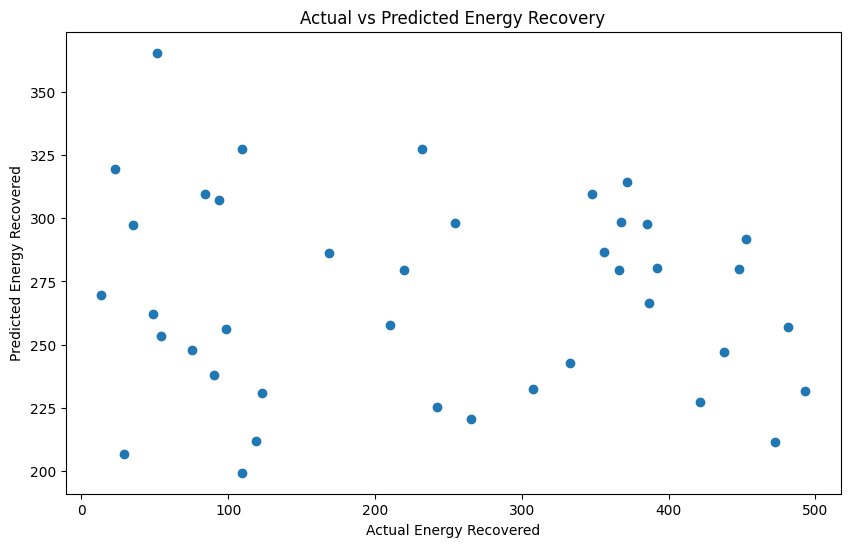

In [229]:
# Visualize Actual vs Predicted values for Energy Recovery
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Energy Recovered')
plt.ylabel('Predicted Energy Recovered')
plt.title('Actual vs Predicted Energy Recovery')
plt.show()

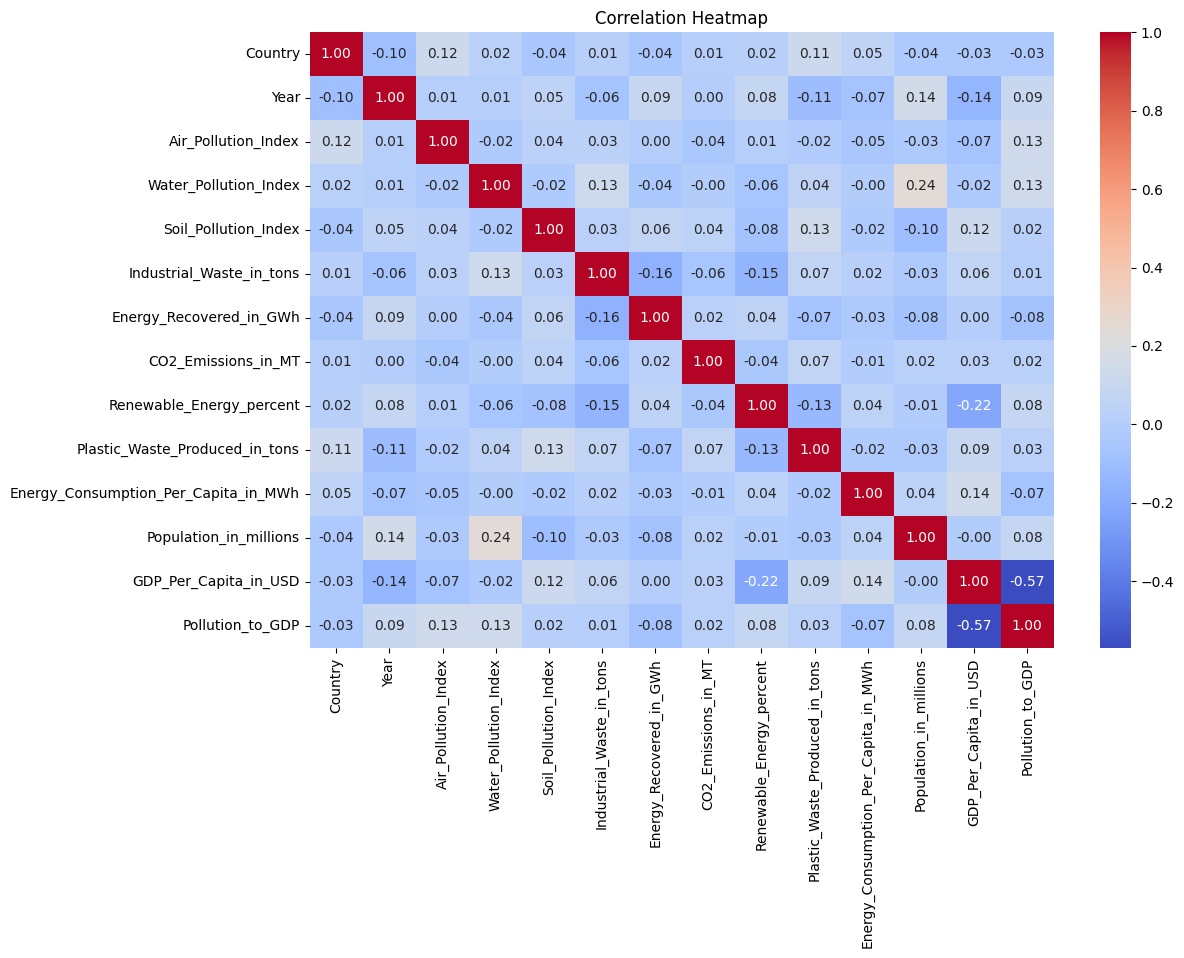

In [230]:
# Correlation Analysis
plt.figure(figsize=(12, 8))
sns.heatmap(df_pollution.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
